<a href="https://colab.research.google.com/github/muneer-ahmad10/Natural-Language-processing/blob/main/Day_24_Revising_basics_Sentiment_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

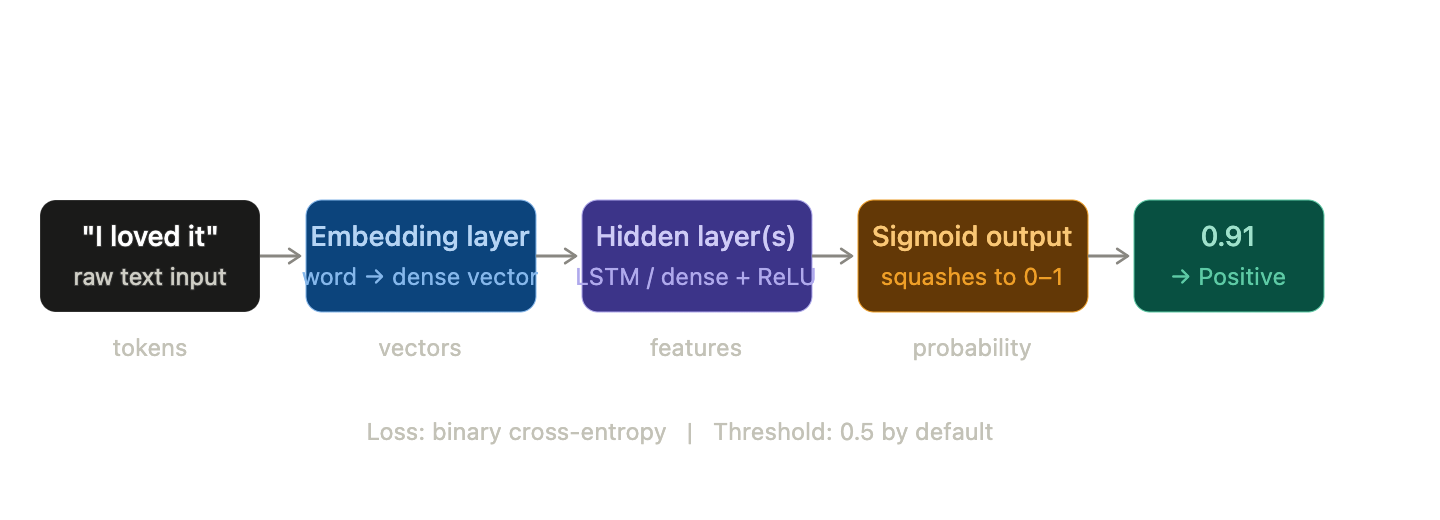

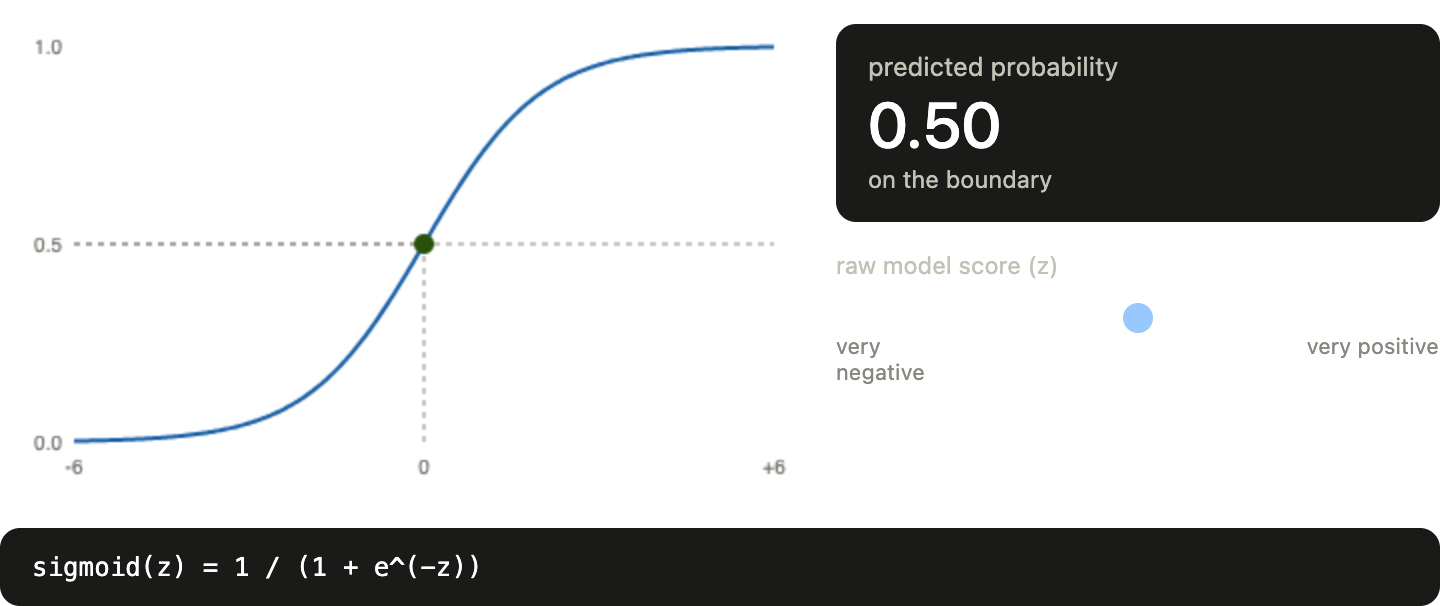

the curve flattens at the extremes (saturation) and is steepest right at z=0 — that's why sigmoid is sensitive near the boundary but barely changes for very confident scores

## **Key concepts**

A sentiment classifier predicts whether text expresses positive, negative (or neutral) sentiment. It's a supervised learning task: you need labeled data (text + sentiment label) to train it.

**Binary vs multi-class**. Binary sentiment (positive/negative) uses sigmoid output + binary cross-entropy loss. Multi-class sentiment (positive/negative/neutral, or 1–5 star ratings) uses softmax output + categorical cross-entropy loss. This distinction is tested constantly.

**Pipeline**. Text gets preprocessed (tokenized, cleaned), converted to embeddings, passed through a model (logistic regression on TF-IDF as a simple baseline, or an LSTM/transformer for deep learning), then squashed to a probability and thresholded.

**Why sigmoid for binary**. Sigmoid maps any real number to a value between 0 and 1, interpretable as "probability of positive class." The default decision threshold is 0.5 — above it predicts positive, below predicts negative.

**Loss function**. Binary cross-entropy (also called log loss) penalizes confident wrong predictions heavily. It's the loss that pairs with sigmoid output, the same way categorical cross-entropy pairs with softmax.

**Evaluation metrics**. Accuracy alone is misleading on imbalanced data (90% positive reviews → a model that always predicts "positive" gets 90% accuracy while being useless). Precision, recall, and F1-score matter more in that case.

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [3]:
texts = ["I loved this movie", "Worst film ever", "Absolutely fantastic",
          "Terrible, waste of time", "Great acting and plot", "I hated it"]
labels = [1, 0, 1, 0, 1, 0] # 1= Positive , 0= Negative

In [4]:
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.33, random_state=42)

In [5]:
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [6]:
clf = LogisticRegression()
clf.fit(X_train_vec, y_train)


LogisticRegression()

In [7]:
preds = clf.predict(X_test_vec)
probs = clf.predict_proba(X_test_vec)[:, 1]

In [8]:
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:

text_preds = ["Positive" if pred == 1 else "Negative" for pred in preds]

print("Predictions:", text_preds)

Predictions: ['Positive', 'Positive']


In [12]:
#Testing

my_sentence = ["The food was absolutely amazing!"]

my_sentence_vec = vectorizer.transform(my_sentence)

raw_pred = clf.predict(my_sentence_vec)[0]

sentiment = "Positive" if raw_pred == 1 else "Negative"

print(f"Text: '{my_sentence[0]}'\nPredicted Sentiment: {sentiment}")

Text: 'The food was absolutely amazing!'
Predicted Sentiment: Positive
